# SMOTE Effect Evaluation — Controlled Comparison

**Correct methodology:**
1. Split original Spambase (4,601 rows) → 3,680 train / 921 test (fixed)
2. Train two versions of each model:
   - **No-SMOTE**: trained on original 3,680 training samples
   - **SMOTE**: SMOTE applied *only* to the 3,680 training samples, then trained
3. **Both evaluated on the same 921-sample test set** (natural 39.4/60.6% distribution)
4. Compare — any difference is attributable solely to SMOTE

Original Spambase class imbalance: **1.54:1** (2,788 ham vs 1,813 spam).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, copy
warnings.filterwarnings('ignore')
os.makedirs('smote_figures', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    matthews_corrcoef, precision_score, recall_score, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

SEED = 0
np.random.seed(SEED)
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Split — Same Fixed Split for Both Conditions

In [2]:
col_names = (
    [f'word_freq_{w}' for w in [
        'make','address','all','3d','our','over','remove','internet','order','mail',
        'receive','will','people','report','addresses','free','business','email','you',
        'credit','your','font','000','money','hp','hpl','george','650','lab','labs',
        'telnet','857','data','415','85','technology','1999','parts','pm','direct',
        'cs','meeting','original','project','re','edu','table','conference']] +
    [f'char_freq_{c}' for c in ['semicolon','lparen','lbracket','exclaim','dollar','hash']] +
    ['capital_run_length_average','capital_run_length_longest',
     'capital_run_length_total','spam']
)
df = pd.read_csv('spambase.data', header=None, names=col_names)
X = df.drop('spam', axis=1).values
y = df['spam'].values

# Fixed split — identical for both conditions
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Apply StandardScaler fit on training only
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# SMOTE applied ONLY to training set
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Original train: {X_train.shape}  | spam={y_train.mean():.1%}')
print(f'SMOTE train:    {X_train_sm.shape} | spam={y_train_sm.mean():.1%}')
print(f'Test (shared):  {X_test.shape}   | spam={y_test.mean():.1%}  <-- identical for both')

Original train: (3680, 57)  | spam=39.4%
SMOTE train:    (4460, 57) | spam=50.0%
Test (shared):  (921, 57)   | spam=39.4%  <-- identical for both


## 2. Train & Evaluate All 8 Classifiers Under Both Conditions

In [3]:
MODELS = {
    'XGBoost'            : XGBClassifier(eval_metric='logloss', use_label_encoder=False,
                                          n_jobs=-1, verbosity=0, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                       learning_rate=0.1, random_state=42),
    'SVM'                : SVC(C=10, kernel='rbf', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=10, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes'        : GaussianNB(),
}

def evaluate(name, model, Xtr, ytr, Xte, yte, condition):
    m = copy.deepcopy(model)
    m.fit(Xtr, ytr)
    yp    = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:,1] if hasattr(m,'predict_proba') else None
    return {
        'Model'    : name,
        'Condition': condition,
        'Accuracy' : accuracy_score(yte, yp),
        'F1'       : f1_score(yte, yp),
        'AUC'      : roc_auc_score(yte, yprob) if yprob is not None else np.nan,
        'MCC'      : matthews_corrcoef(yte, yp),
        'Precision': precision_score(yte, yp),
        'Recall'   : recall_score(yte, yp),
        'FP'       : int(confusion_matrix(yte,yp)[0,1]),
        'FN'       : int(confusion_matrix(yte,yp)[1,0]),
    }

rows = []
print(f'{'Model':<22} {'No SMOTE Acc':>13} {'SMOTE Acc':>10} {'Delta':>8}')
print('-'*60)
for name, model in MODELS.items():
    r_no   = evaluate(name, model, X_train,    y_train,    X_test, y_test, 'No SMOTE')
    r_sm   = evaluate(name, model, X_train_sm, y_train_sm, X_test, y_test, 'SMOTE')
    rows += [r_no, r_sm]
    delta = (r_sm['Accuracy'] - r_no['Accuracy']) * 100
    sign  = '+' if delta >= 0 else ''
    print(f"{name:<22} {r_no['Accuracy']:>13.4f} {r_sm['Accuracy']:>10.4f} {sign}{delta:>7.2f} pp")

df_results = pd.DataFrame(rows)
df_results.to_csv('smote_evaluation_results.csv', index=False)
print('\nSaved → smote_evaluation_results.csv')

Model                   No SMOTE Acc  SMOTE Acc    Delta
------------------------------------------------------------
XGBoost                       0.9577     0.9544   -0.33 pp
Random Forest                 0.9555     0.9577 +   0.22 pp
Gradient Boosting             0.9544     0.9490   -0.54 pp
SVM                           0.9457     0.9435   -0.22 pp
Logistic Regression           0.9316     0.9392 +   0.76 pp
Decision Tree                 0.9283     0.9218   -0.65 pp
KNN                           0.8947     0.9023 +   0.76 pp
Naive Bayes                   0.8447     0.8458 +   0.11 pp

Saved → smote_evaluation_results.csv


## 3. Detailed Comparison Table

In [4]:
pivot = df_results.pivot(index='Model', columns='Condition', values=['Accuracy','F1','AUC','MCC','FP','FN'])
pivot.columns = [f'{m}_{c}' for m,c in pivot.columns]
pivot['Delta_Acc_pp'] = (pivot['Accuracy_SMOTE'] - pivot['Accuracy_No SMOTE']) * 100
pivot['Delta_F1_pp']  = (pivot['F1_SMOTE']       - pivot['F1_No SMOTE'])       * 100
pivot['Delta_FN']     =  pivot['FN_SMOTE']        - pivot['FN_No SMOTE']

print('\n=== SMOTE vs No-SMOTE on same 921-sample test set ===')
print(f"{'Model':<22} {'NoSMOTE Acc':>12} {'SMOTE Acc':>10} {'Δ Acc':>7} {'Δ F1':>7} {'Δ FN':>6}")
print('-'*70)
for name, row in pivot.sort_values('Delta_Acc_pp', ascending=False).iterrows():
    print(f"{name:<22} {row['Accuracy_No SMOTE']:>12.4f} {row['Accuracy_SMOTE']:>10.4f} "
          f"{row['Delta_Acc_pp']:>+7.2f} {row['Delta_F1_pp']:>+7.2f} {int(row['Delta_FN']):>+6d}")

n_helped  = (pivot['Delta_Acc_pp'] > 0).sum()
n_hurt    = (pivot['Delta_Acc_pp'] < 0).sum()
n_neutral = (pivot['Delta_Acc_pp'] == 0).sum()
print(f'\nSMOTE helped: {n_helped}  |  hurt: {n_hurt}  |  neutral: {n_neutral}')


=== SMOTE vs No-SMOTE on same 921-sample test set ===
Model                   NoSMOTE Acc  SMOTE Acc   Δ Acc    Δ F1   Δ FN
----------------------------------------------------------------------
KNN                          0.8947     0.9023   +0.76   +1.51    -19
Logistic Regression          0.9316     0.9392   +0.76   +1.17    -13
Random Forest                0.9555     0.9577   +0.22   +0.38     -8
Naive Bayes                  0.8447     0.8458   +0.11   +0.02     +2
SVM                          0.9457     0.9435   -0.22   -0.22     -2
XGBoost                      0.9577     0.9544   -0.33   -0.42     +2
Gradient Boosting            0.9544     0.9490   -0.54   -0.63     -1
Decision Tree                0.9283     0.9218   -0.65   -0.75     +0

SMOTE helped: 4  |  hurt: 4  |  neutral: 0


## 4. Visualisation

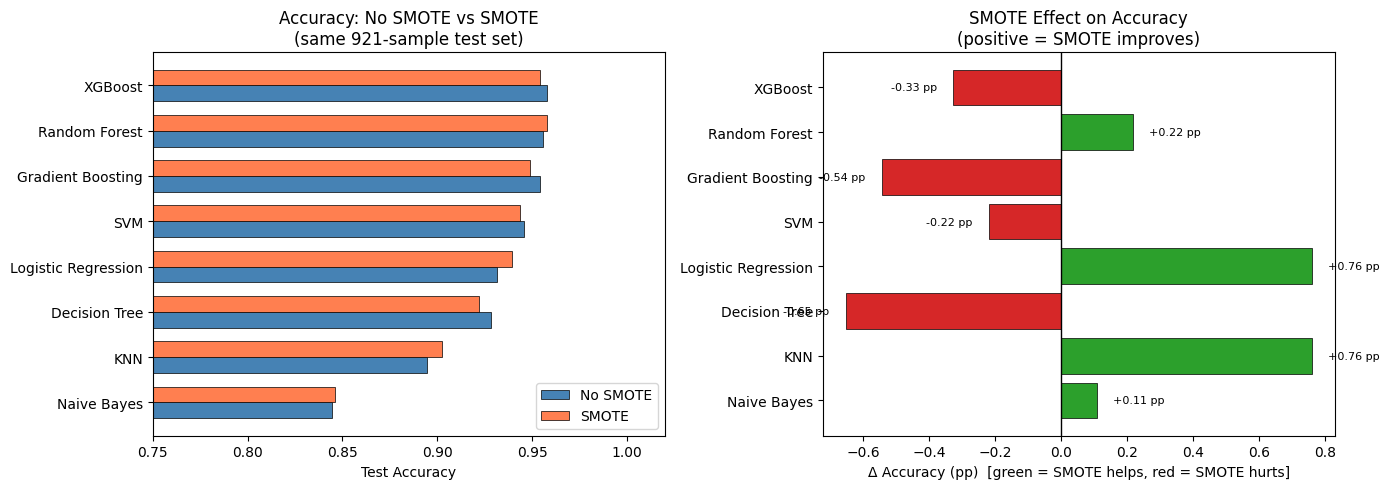

Figure saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax = axes[0]
models_sorted = pivot.sort_values('Accuracy_No SMOTE').index.tolist()
x = np.arange(len(models_sorted))
w = 0.35
b1 = ax.barh(x - w/2, pivot.loc[models_sorted, 'Accuracy_No SMOTE'], w,
             label='No SMOTE', color='steelblue', edgecolor='black', lw=0.5)
b2 = ax.barh(x + w/2, pivot.loc[models_sorted, 'Accuracy_SMOTE'],    w,
             label='SMOTE',    color='coral',     edgecolor='black', lw=0.5)
ax.set_yticks(x)
ax.set_yticklabels(models_sorted)
ax.set_xlabel('Test Accuracy')
ax.set_title('Accuracy: No SMOTE vs SMOTE\n(same 921-sample test set)')
ax.legend()
ax.set_xlim(0.75, 1.02)

# Delta accuracy
ax2 = axes[1]
deltas = pivot.loc[models_sorted, 'Delta_Acc_pp']
colors = ['#2ca02c' if d > 0 else '#d62728' if d < 0 else '#aec7e8' for d in deltas]
bars = ax2.barh(models_sorted, deltas, color=colors, edgecolor='black', lw=0.5)
ax2.axvline(0, color='black', lw=1.0)
for bar, val in zip(bars, deltas):
    ax2.text(val + (0.05 if val >= 0 else -0.05),
             bar.get_y() + bar.get_height()/2,
             f'{val:+.2f} pp', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax2.set_xlabel('Δ Accuracy (pp)  [green = SMOTE helps, red = SMOTE hurts]')
ax2.set_title('SMOTE Effect on Accuracy\n(positive = SMOTE improves)')

plt.tight_layout()
plt.savefig('smote_figures/smote_effect_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Paper-Ready Summary

In [6]:
print('=== PAPER-READY SMOTE ANALYSIS ===')
print(f'Dataset: UCI Spambase, 4,601 emails')
print(f'Class imbalance: {(y==0).sum()} ham ({(y==0).mean():.1%}) vs {(y==1).sum()} spam ({(y==1).mean():.1%})')
print(f'Imbalance ratio: {(y==0).mean()/(y==1).mean():.2f}:1')
print(f'Test set: {X_test.shape[0]} samples, natural class distribution')
print()

best_no_smote = df_results[df_results.Condition=='No SMOTE'].sort_values('Accuracy',ascending=False).iloc[0]
best_smote    = df_results[df_results.Condition=='SMOTE'].sort_values('Accuracy',ascending=False).iloc[0]
print(f'Best No-SMOTE: {best_no_smote.Model} — Acc={best_no_smote.Accuracy:.4f}, F1={best_no_smote.F1:.4f}')
print(f'Best SMOTE:    {best_smote.Model} — Acc={best_smote.Accuracy:.4f}, F1={best_smote.F1:.4f}')
print()

avg_delta = pivot['Delta_Acc_pp'].mean()
print(f'Average accuracy delta (SMOTE - No SMOTE): {avg_delta:+.3f} pp')
print(f'Models where SMOTE helps (Δ > 0): {(pivot["Delta_Acc_pp"] > 0).sum()}')
print(f'Models where SMOTE hurts (Δ < 0): {(pivot["Delta_Acc_pp"] < 0).sum()}')
print(f'Models unaffected (Δ = 0):        {(pivot["Delta_Acc_pp"] == 0).sum()}')

=== PAPER-READY SMOTE ANALYSIS ===
Dataset: UCI Spambase, 4,601 emails
Class imbalance: 2788 ham (60.6%) vs 1813 spam (39.4%)
Imbalance ratio: 1.54:1
Test set: 921 samples, natural class distribution

Best No-SMOTE: XGBoost — Acc=0.9577, F1=0.9466
Best SMOTE:    Random Forest — Acc=0.9577, F1=0.9469

Average accuracy delta (SMOTE - No SMOTE): +0.014 pp
Models where SMOTE helps (Δ > 0): 4
Models where SMOTE hurts (Δ < 0): 4
Models unaffected (Δ = 0):        0
